In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\Marcus\Desktop\python pandas\superstore_data\version_control\superstore_clean.csv')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,31518,CA-2012-169397,2012-12-24,2013-01-09,First Class,JB-15925,Joni Blumstein,Consumer,Dublin,Ohio,...,OFF-BI-10002852,Office Supplies,Binders,Ibico Standard Transparent Covers,19.7760,4,0.70,-13.84,0.79,Medium
1,6224,US-2011-144729,2011-07-21,2011-08-07,First Class,SS-20140,Saphhira Shifley,Corporate,San Miguelito,Panama,...,OFF-FA-10002247,Office Supplies,Fasteners,"Oic Paper Clips, Bulk Pack",11.5440,2,0.40,-5.22,0.97,Medium
2,15333,IT-2014-4749412,2014-09-18,2014-09-28,Standard Class,MB-18085,Mick Brown,Unknown,Birmingham,England,...,OFF-AR-10003113,Office Supplies,Art,"Binney & Smith Pens, Blue",29.8500,5,0.50,-4.80,3.71,Medium
3,49259,NI-2013-4420,2013-04-10,2013-10-26,Standard Class,MP-7965,Michael Paige,Corporate,Lagos,Lagos,...,OFF-AVE-10004512,Office Supplies,Binders,"Avery Hole Reinforcements, Economy",1.3230,1,0.70,-3.09,0.06,Medium
4,24199,IN-2014-14423,2014-10-29,2014-11-27,First Class,DL-12925,Daniel Lacy,Consumer,Kendari,Sulawesi Tenggara,...,FUR-FU-10002362,Furnitures,Furnishings,"Advantus Door Stop, Black",131.4876,4,0.27,25.17,0.00,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51365,17526,ES-2014-2057259,2014-08-02,2014-05-19,First Class,PB-19150,Philip Brown,Consumer,Cagnes-Sur-Mer,Provence-Alpes-Cote D'Azur,...,OFF-PA-10002616,Office Supplies,Paper,"Green Bar Parchment Paper, Multicolor",108.5400,6,0.00,34.56,11.76,Medium
51366,36055,CA-2011-121573,2011-11-03,2011-08-07,Standard Class,SG-20605,Speros Goranitis,Consumer,New York City,New York,...,TEC-PH-10000984,Technology,Phones,Panasonic Kx-Tg9471B,783.9600,4,0.00,219.51,64.42,High
51367,43576,TU-2011-9190,2011-12-23,2012-01-11,Second Class,CM-1830,Cari Macintyre,Corporate,Corum,Corum,...,OFF-KIT-10002357,Office Supplies,Appliances,"Kitchenaid Blender, White",39.8400,1,0.60,-12.96,5.84,Medium
51368,22403,IN-2013-35388,2013-08-07,2013-11-19,Standard Class,IM-15055,Unknown,Consumer,Jakarta,Jakarta,...,OFF-AR-10000058,Office Supplies,Art,"Stanley Canvas, Water Color",38.4345,1,0.27,3.66,2.96,Medium


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51370 entries, 0 to 51369
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51370 non-null  int64  
 1   Order ID        51370 non-null  str    
 2   Order Date      51370 non-null  str    
 3   Ship Date       51370 non-null  str    
 4   Ship Mode       51370 non-null  str    
 5   Customer ID     51370 non-null  str    
 6   Customer Name   51336 non-null  str    
 7   Segment         51370 non-null  str    
 8   City            51351 non-null  str    
 9   State           51339 non-null  str    
 10  Country         51370 non-null  str    
 11  Postal Code     51370 non-null  int64  
 12  Market          51370 non-null  str    
 13  Region          51370 non-null  str    
 14  Product ID      51370 non-null  str    
 15  Category        51370 non-null  str    
 16  Sub-Category    51370 non-null  str    
 17  Product Name    51370 non-null  str    
 1

In [4]:
# Are high discounts effectively driving up the transaction Volume (Quantity), or are they just reducing margins without shifting inventory?

In [5]:
sales_profit_txn_by_discount = df.groupby(
    df['Discount'].rename('discount')
)[
    [
        'Sales',
        'Profit',
        'Discount'
    ]
].agg(
    total_sales = ('Sales','sum'),
    total_profit = ('Profit','sum'),
    number_of_transaction =  ('Discount','count'),
).round(2)
sales_profit_txn_by_discount

,total_sales,total_profit,number_of_transaction
discount,,,
0.00,7362500.92,1819407.25,29926
0.07,121032.22,20953.73,149
0.10,1555613.58,254546.00,3989
0.15,303807.61,26970.24,534
0.17,247412.20,28363.46,727
0.20,1203457.84,114491.08,4970
0.25,86051.31,324.33,196
0.27,87776.46,-1502.49,380
0.30,187627.97,-19702.58,335


In [6]:
sales_profit_txn_by_discount['profit_margin'] = (sales_profit_txn_by_discount['total_sales'] / sales_profit_txn_by_discount['total_profit']).round(2)

In [7]:
sales_profit_txn_by_discount

,total_sales,total_profit,number_of_transaction,profit_margin
discount,,,,
0.00,7362500.92,1819407.25,29926,4.05
0.07,121032.22,20953.73,149,5.78
0.10,1555613.58,254546.00,3989,6.11
0.15,303807.61,26970.24,534,11.26
0.17,247412.20,28363.46,727,8.72
0.20,1203457.84,114491.08,4970,10.51
0.25,86051.31,324.33,196,265.32
0.27,87776.46,-1502.49,380,-58.42
0.30,187627.97,-19702.58,335,-9.52


In [8]:
sales_profit_txn_by_discount.reset_index(inplace=True)

In [9]:
sales_profit_txn_by_discount

,discount,total_sales,total_profit,number_of_transaction,profit_margin
0,0.00,7362500.92,1819407.25,29926,4.05
1,0.07,121032.22,20953.73,149,5.78
2,0.10,1555613.58,254546.00,3989,6.11
3,0.15,303807.61,26970.24,534,11.26
4,0.17,247412.20,28363.46,727,8.72
5,0.20,1203457.84,114491.08,4970,10.51
6,0.25,86051.31,324.33,196,265.32
7,0.27,87776.46,-1502.49,380,-58.42
8,0.30,187627.97,-19702.58,335,-9.52
9,0.32,14493.46,-2391.16,27,-6.06


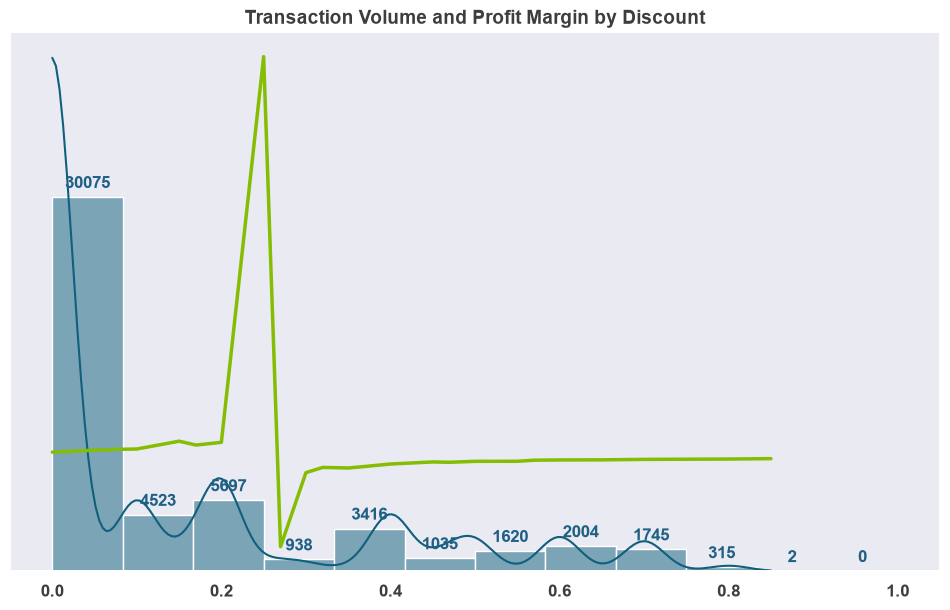

In [100]:
sns.set_theme()

fig, ax = plt.subplots(figsize=(12,7))

ax = sns.histplot(
    data=df, 
    x="Discount",
    stat='count',
    bins=12,
    binrange=[0.00,1.00],
    kde=True,
    color='#105F7D'
)
ax.set_title('Transaction Volume and Profit Margin by Discount', fontsize=14, color='#3D3D40', fontweight='bold')
ax.grid(False)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticklabels([])
ax.set_yticks([])
ax.tick_params(axis='x', labelsize=12, labelcolor='#3D3D40')
for label in ax.get_xticklabels():
    label.set_weight('bold')

ax1 = ax.twinx()

ax1 = sns.lineplot(
    data=sales_profit_txn_by_discount,
    x='discount',
    y='profit_margin',
    color='#84BD01',
    linewidth=2.5
)
ax1.grid(False)
ax1.set_ylabel('')
ax1.set_yticklabels([])
ax1.set_yticks([])

for container in ax.containers:
    ax.bar_label(container, padding=4, fontsize=12, color='#206085', fontweight='bold')

In [102]:
# Business Question 16:
# Are high discounts effectively driving up the transaction Volume (Quantity), or are they just reducing margins without shifting inventory?

# Answer:
# Transaction Volume from 25% above discount displays lower than 4k transaction in every discount bracket, but below 25% discount shows great volume
# particularly around 10% discount leads in 30k in purchase. Discount from 20% to 25% portrays a massive profit gains but dives deeply when discount
# is higher than 25%. To maintain profit growth, operate around from 20% to 25% discount to every orders.